**Non-interactive rerun:** `scripts/run_player_projection.py` (Phase 0 only —
Phase 1 has no production script; this notebook (Cells 8-12) is the canonical
Phase 1 diagnostic, superseding the earlier one-off `validate_phase1_kalman.py`).

In [1]:
# Cell 0 — Imports + Config
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import text

from portalpoint.modeling import player_projection as pp
from portalpoint.modeling import player_projection_kalman as ppk
from portalpoint.modeling.io import find_repo_root, get_sync_engine

warnings.filterwarnings('ignore')

ROOT = find_repo_root()
engine = get_sync_engine()

SEASONS_IN_DATA = [2021, 2022, 2023, 2024, 2025, 2026]
CURRENT_SEASON = max(SEASONS_IN_DATA)
GAME_LOG_SEASON = 2026  # Phase 1 scope — see Cell 1 coverage audit

MODEL_VERSION_PHASE0 = pp.MODEL_VERSION
MIN_GAMES = pp.MIN_GAMES
SKILLS = pp.SKILLS

print('Config loaded — seasons:', SEASONS_IN_DATA)
print('Phase 0 model version:', MODEL_VERSION_PHASE0)
print('Phase 1 game-log season:', GAME_LOG_SEASON)


Config loaded — seasons: [2021, 2022, 2023, 2024, 2025, 2026]
Phase 0 model version: player-projection-shrinkage-v1
Phase 1 game-log season: 2026


## 1. Data Coverage Audit

`hoopr_player_game_logs` was backfilled to 2020-2026 (2026-06-23) — see
`docs/status/ARCHITECTURE_STATUS.md`. This unblocks Phase 2 (cross-season
`rho`/development-curve fitting) data-wise, but Phase 2 is **not** built in
this notebook — Phase 1 below is still single-season (2026), since the point
of Phase 1 is to validate the state-space machinery on one season before
adding cross-season complexity on top of it (plan doc §15).


In [2]:
# Cell 1 — Game-log coverage audit
with engine.connect() as conn:
    coverage = pd.read_sql(
        text('SELECT season, COUNT(*) AS n_player_games FROM hoopr_player_game_logs GROUP BY season ORDER BY season'),
        conn,
    )
print(coverage.to_string(index=False))
print(f"\nSeasons with game-level data: {coverage['season'].tolist()}")
print('Phase 2 (cross-season rho, dev curve) is now data-unblocked but is a separate follow-up.')


 season  n_player_games
   2020          162813
   2021          121547
   2022          171896
   2023          176962
   2024          180527
   2025          184504
   2026          178108

Seasons with game-level data: [2020, 2021, 2022, 2023, 2024, 2025, 2026]
Phase 2 (cross-season rho, dev curve) is now data-unblocked but is a separate follow-up.


## 2. Phase 0 — Load Player-Season Data

Pulls season-grain rate stats from `player_season_stats`, LEFT JOINed to
`hoop_explorer_player_stats` for the RAPM value-model labels (`off_adj_rapm`,
`def_adj_rapm`) and `pos_class` for position grouping.

**Why `pos_class`, not `players.position`:** discovered while building Phase 0
that `players.position` is the literal string `'G'` for all 13,303 players —
zero variation, despite the column comment claiming PG/SG/SF/PF/C. Documented in `player_projection.py`'s module docstring. **Fixed upstream 2026-06-23** (re-ran
`ingest_barttorvik.py` after the `_infer_position()` fix landed) — `players.position`
now has a real PG/SG/SF/PF/C distribution, but this notebook still uses HE `pos_class`
for position grouping (no need to switch, both are real now; revisiting which should be
primary is tracked in BRANCH_TODO.md, not blocking).


In [3]:
# Cell 2 — Load player-season data (mirrors scripts/run_player_projection.py)
PLAYER_SQL = '''
SELECT
    pss.player_id, pss.season, he.pos_class AS position,
    pss.games_played, pss.min_pct,
    pss.fg3_pct, pss.rim_pct, pss.ft_pct, pss.usage_rate, pss.assist_rate,
    pss.tov_pct, pss.off_reb_pct, pss.def_reb_pct, pss.steal_pct, pss.block_pct,
    he.off_adj_rapm, he.def_adj_rapm, he.off_adj_rapm_prod, he.adj_rapm_prod_margin
FROM player_season_stats pss
LEFT JOIN hoop_explorer_player_stats he
    ON he.player_id = pss.player_id AND he.season = pss.season
WHERE pss.games_played >= :min_games
'''
with engine.connect() as conn:
    player_df = pd.read_sql(text(PLAYER_SQL), conn, params={'min_games': MIN_GAMES})
player_df = player_df.drop_duplicates(subset=['player_id', 'season'], keep='first').reset_index(drop=True)

print(f'Loaded {len(player_df):,} player-seasons (games_played >= {MIN_GAMES})')
print('\nRows per season:')
print(player_df['season'].value_counts().sort_index())
he_cov = player_df[['off_adj_rapm', 'def_adj_rapm']].dropna().shape[0]
print(f'\nHE-labeled rows (value-model training set): {he_cov:,}/{len(player_df):,} ({100*he_cov/len(player_df):.1f}%)')


Loaded 27,047 player-seasons (games_played >= 5)

Rows per season:
season
2021    4266
2022    4538
2023    4556
2024    4565
2025    4571
2026    4551
Name: count, dtype: int64

HE-labeled rows (value-model training set): 16,178/27,047 (59.8%)


## 3. Phase 0 — Empirical-Bayes Shrinkage + Skill Percentiles

Each raw skill rate is shrunk toward its position (`pos_class`) x season prior,
weighted by `games_played x min_pct` — more games and a larger share of team
minutes means less shrinkage toward the prior. `foul_discipline` is omitted —
no foul-rate column exists at season grain.

`skill_percentiles` ranks each shrunk skill within-season; `turnover_avoidance`'s
direction is flipped so a higher percentile always means "better" (lower
turnover rate), matching every other skill's convention.


Shrinkage spot-check — first 5 players, shooting_3p:


 player_id  season  raw_shooting_3p  prior_shooting_3p  skill_shooting_3p  _weight
     25852    2021            0.440              0.311              0.409   25.344
     27624    2021            0.273              0.212              0.257   22.432
     25954    2021            0.447              0.327              0.417   24.240
     26021    2021            0.440              0.212              0.384   24.428
     26043    2021            0.304              0.327              0.310   26.016


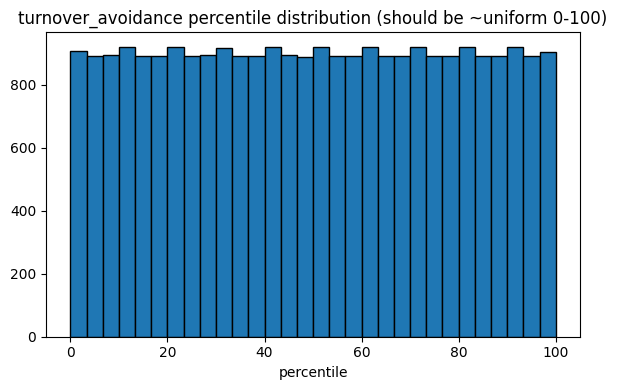

In [4]:
# Cell 3 — Shrinkage + percentiles
shrunk_df = pp.shrink_skills(player_df)
pctile_df = pp.skill_percentiles(shrunk_df)

print('Shrinkage spot-check — first 5 players, shooting_3p:')
spot = pctile_df[['player_id', 'season', 'raw_shooting_3p', 'prior_shooting_3p', 'skill_shooting_3p', '_weight']].head()
print(spot.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(pctile_df['pctile_turnover_avoidance'], bins=30, edgecolor='black')
ax.set_title('turnover_avoidance percentile distribution (should be ~uniform 0-100)')
ax.set_xlabel('percentile')
plt.tight_layout()
plt.show()


## 4. Phase 0 — Value-Translation Model (Ridge vs. Hoop Explorer RAPM)

Regresses shrunk skills + position dummies on `off_adj_rapm`/`def_adj_rapm`.
These remain the primary training targets. `off_adj_rapm_prod`/`adj_rapm_prod_margin`
are also now ingested and used as a robustness check (not a retrain target) in Cell 5 —
see plan doc §5/§8 for the full corrected Hoop Explorer field inventory.


off_resid_std=1.586  def_resid_std=1.515

Ridge coefficients (skill -> RAPM):
                       off_coef  def_coef
skill                                    
shooting_3p               0.650    -0.077
shooting_2p_finishing     0.846    -0.198
free_throw_touch          0.642    -0.112
shot_creation_usage      -0.096     0.265
passing_creation          1.110    -0.381
turnover_avoidance       -0.957     0.171
offensive_rebounding      1.149    -0.211
defensive_rebounding      0.015    -0.170
steal_disruption         -0.033    -0.356
block_rim_protection      0.015    -0.383


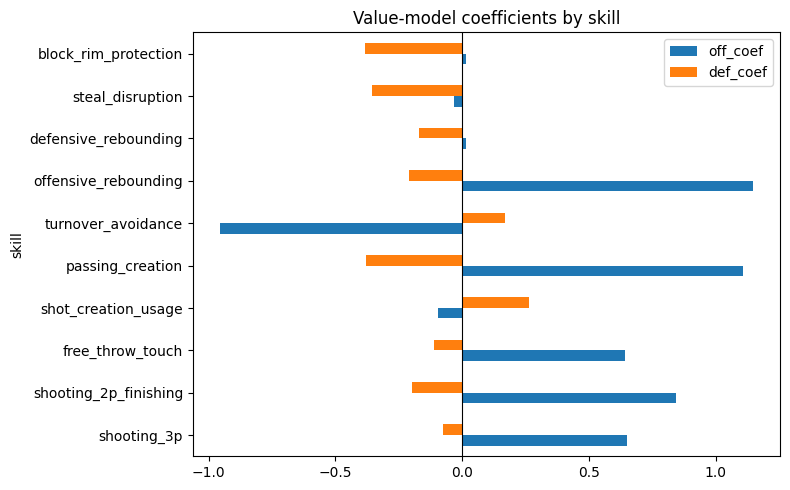

Saved off_model: C:\Users\shant\Desktop\MIDS\MIDS210-Capstone\data\models\player_projection_off_model.pkl
Saved def_model: C:\Users\shant\Desktop\MIDS\MIDS210-Capstone\data\models\player_projection_def_model.pkl
Saved bundle: C:\Users\shant\Desktop\MIDS\MIDS210-Capstone\data\models\player_projection_model_bundle.pkl


  → s3://portalpoint-data/models/player_projection/player_projection_off_model.pkl


  → s3://portalpoint-data/models/player_projection/player_projection_def_model.pkl


  → s3://portalpoint-data/models/player_projection/player_projection_model_bundle.pkl


In [5]:
# Cell 4 — Fit value models + diagnostics
off_model, off_resid_std = pp.fit_value_model(pctile_df, 'off_adj_rapm')
def_model, def_resid_std = pp.fit_value_model(pctile_df, 'def_adj_rapm')
print(f'off_resid_std={off_resid_std:.3f}  def_resid_std={def_resid_std:.3f}')

coef_df = pd.DataFrame({
    'skill': SKILLS,
    'off_coef': off_model.named_steps['ridge'].coef_[:len(SKILLS)],
    'def_coef': def_model.named_steps['ridge'].coef_[:len(SKILLS)],
}).set_index('skill')
print('\nRidge coefficients (skill -> RAPM):')
print(coef_df.round(3).to_string())

fig, ax = plt.subplots(figsize=(8, 5))
coef_df.plot.barh(ax=ax)
ax.set_title('Value-model coefficients by skill')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()


# Local pkl + S3 upload -- same convention as player_clustering.py /
# team_clustering.py (save_artifacts + s3_helpers.upload), separate from
# MLflow's own log_model/artifact store in Cell 7.
model_paths = pp.save_artifacts(ROOT / 'data' / 'models', off_model, def_model, off_resid_std, def_resid_std)
for _name, _path in model_paths.items():
    print(f'Saved {_name}: {_path}')
try:
    import sys as _sys
    _sys.path.insert(0, str(ROOT / 'notebooks' / 'utils'))
    from s3_helpers import upload as _upload
    for _name, _path in model_paths.items():
        _upload(_path, f'models/player_projection/{_path.name}')
except Exception as _exc:
    print(f'S3 upload skipped: {_exc}')


## 5. Phase 0 — Projection + Spot Check

Applies the fitted value models to **every** player with season stats, not
just the Hoop-Explorer-matched training subset — that's what makes this a
projection rather than a label lookup.


In [6]:
# Cell 5 — Project value + spot check top players
projected_df = pp.project_value(pctile_df, off_model, def_model, off_resid_std, def_resid_std)

with engine.connect() as conn:
    names = pd.read_sql(text('SELECT id AS player_id, full_name FROM players'), conn)
top10 = (
    projected_df[projected_df['season'] == CURRENT_SEASON]
    .merge(names, on='player_id', how='left')
    .sort_values('value_per_100', ascending=False)
    .head(10)[['full_name', 'value_per_100', 'value_ci_lower', 'value_ci_upper']]
)
print(f'Top 10 projected value_per_100, season {CURRENT_SEASON}:')
print(top10.round(2).to_string(index=False))

# Robustness check (plan doc section 5/8): off_adj_rapm_prod / adj_rapm_prod_margin mix
# per-possession impact with playing-time share, so they are not retraining
# targets, but the projection should still track them directionally.
prod_check = projected_df[['off_value_per_100', 'off_adj_rapm_prod']].dropna()
prod_corr = prod_check['off_value_per_100'].corr(prod_check['off_adj_rapm_prod'])
print('Robustness check: off_value_per_100 vs off_adj_rapm_prod corr=' + format(prod_corr, '.3f') + ' (n=' + format(len(prod_check), ',') + ')')
margin_check = projected_df[['value_per_100', 'adj_rapm_prod_margin']].dropna()
margin_corr = margin_check['value_per_100'].corr(margin_check['adj_rapm_prod_margin'])
print('Robustness check: value_per_100 vs adj_rapm_prod_margin corr=' + format(margin_corr, '.3f') + ' (n=' + format(len(margin_check), ',') + ')')


Top 10 projected value_per_100, season 2026:


        full_name  value_per_100  value_ci_lower  value_ci_upper
     Malique Ewin           5.04            2.23            7.85
   Bruce Thornton           4.69            1.88            7.50
 Jeremy Fears Jr.           4.69            1.88            7.50
    Joseph Tugler           4.68            1.87            7.50
       Tobe Awaka           4.61            1.80            7.42
 Darius Acuff Jr.           4.47            1.66            7.29
Trey Kaufman-Renn           4.43            1.62            7.24
 Ryan Prather Jr.           4.41            1.60            7.22
      Oscar Cluff           4.36            1.55            7.17
  Nick Martinelli           4.20            1.39            7.01
Robustness check: off_value_per_100 vs off_adj_rapm_prod corr=0.644 (n=16,178)
Robustness check: value_per_100 vs adj_rapm_prod_margin corr=0.438 (n=16,178)


## 6. Phase 0 — Write to `player_projections`

Neutral-mode rows only (`school_id` NULL). Upserts via the partial unique
index on `(player_id, season, model_version) WHERE school_id IS NULL` — safe
to rerun. Same write path `scripts/run_player_projection.py` uses.


In [7]:
# Cell 6 — Write neutral projections
records = pp.build_neutral_records(projected_df)
upserted = pp.upsert_neutral_projections(engine, records)
print(f'Upserted {upserted:,} rows into player_projections (neutral mode)')


Upserted 27,047 rows into player_projections (neutral mode)


## 7. Phase 0 — MLflow Tracking


In [8]:
# Cell 7 — MLflow tracking (mirrors scheme_fit_scorer.ipynb / gap_matching.ipynb)
import mlflow
import mlflow.pyfunc
from portalpoint.modeling.mlflow_helpers import setup_mlflow, maybe_promote

values = np.array([r[4] for r in records], dtype=np.float64)
mean_value, std_value = float(values.mean()), float(values.std())
total_resid_std = float(np.sqrt(off_resid_std**2 + def_resid_std**2))

class PlayerProjectionPyfunc(mlflow.pyfunc.PythonModel):
    def __init__(self, off_model, def_model):
        self.off_model = off_model
        self.def_model = def_model

    def predict(self, context, model_input):
        X = pp.build_design_matrix(model_input)
        off = self.off_model.predict(X)
        defn = self.def_model.predict(X)
        return [{'value_per_100': float(o + d)} for o, d in zip(off, defn)]

client = setup_mlflow('player-projection')
with mlflow.start_run(run_name=f'player-projection-s{CURRENT_SEASON}-notebook') as run:
    mlflow.log_params({
        'seasons': ','.join(str(s) for s in SEASONS_IN_DATA),
        'model_version': MODEL_VERSION_PHASE0,
        'min_games': MIN_GAMES,
        'source': 'notebook',
    })
    mlflow.log_metrics({
        'mean_value_per_100': mean_value,
        'std_value_per_100': std_value,
        'off_resid_std': off_resid_std,
        'def_resid_std': def_resid_std,
        'total_resid_std': total_resid_std,
        'n_records_written': float(len(records)),
    })
    mlflow.pyfunc.log_model(artifact_path='player_projection_model', python_model=PlayerProjectionPyfunc(off_model, def_model))
    run_id = run.info.run_id

result = maybe_promote(client, 'player-projection', run_id, 'player_projection_model',
                        metric_name='total_resid_std', new_value=total_resid_std, higher_is_better=False)
print(f'Run ID: {run_id}')
print(f'Registry: {result}')


c:\Users\shant\Desktop\MIDS\MIDS210-Capstone\.venv\Lib\site-packages\mlflow\pyfunc\utils\data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


2026/06/24 20:16:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/06/24 20:16:16 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.


2026/06/24 20:16:36 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Registered model 'player-projection' already exists. Creating a new version of this model...


2026/06/24 20:16:38 WARNING mlflow.tracking._model_registry.fluent: Run with id ae6dbaa41bf9458c8f31ebed8bb07b19 has no artifacts at artifact path 'player_projection_model', registering model based on models:/m-86f714cefb994dd2ae315286e3622117 instead


Created version '19' of model 'player-projection'.


Run ID: ae6dbaa41bf9458c8f31ebed8bb07b19
Registry: staging — player-projection v19 → Staging (Δ=+0.1%)


## 7a. Phase 0 — Formal Rolling-Origin Evaluation

Phase 0 had no held-out validation at all until now -- `off_resid_std`/`def_resid_std`
above are in-sample (fit and evaluated on the same rows), and `SHRINKAGE_K`/`RIDGE_ALPHA`
were hardcoded, never tuned. This section replaces that with real rolling-origin temporal
CV per plan doc Section 12.

**3 folds, all chronological** (train on past seasons, test on the next one):

| Fold | Train | Validation (hyperparameter selection only) | Test |
|---|---|---|---|
| 1 | 2021-2022 | 2023 | 2024 |
| 2 | 2021-2023 | 2024 | 2025 |
| 3 | 2021-2024 | 2025 | **2026 (headline)** |

Hyperparameters (`SHRINKAGE_K`, `RIDGE_ALPHA`) are grid-searched on each fold's validation
season only, never on test. **Known, accepted limitation:** the same player can appear in
both a fold's train and test seasons as different season-observations -- not eliminable
without sacrificing most of the test set, standard for this kind of repeated-measures sports
panel, not a clean player-disjoint holdout.

**This evaluation does not change production** -- `run_player_projection.py` keeps fitting on
the full pooled 2021-2026 population with its current defaults unless these results give a
specific reason to change them.


In [9]:
# Cell 7a-1 -- Rolling-origin folds, hyperparameter tuning, held-out test metrics
from portalpoint.modeling import player_projection_eval as ppe

folds = ppe.make_rolling_origin_folds(player_df)
fold_results = []
fold_artifacts = []  # keep fold 3's fitted models/frames for the cells below

for i, fold in enumerate(folds, 1):
    train_df, val_df, test_df = fold["train"], fold["val"], fold["test"]
    k, alpha, grid_df = ppe.tune_hyperparameters(train_df, val_df)

    train_val_df = pd.concat([train_df, val_df], ignore_index=True)
    shrunk_tv = pp.shrink_skills(train_val_df, k=k)
    shrunk_test = pp.shrink_skills(test_df, k=k)
    off_model_cv, off_resid_std_cv = pp.fit_value_model(shrunk_tv, "off_adj_rapm", alpha=alpha)
    def_model_cv, def_resid_std_cv = pp.fit_value_model(shrunk_tv, "def_adj_rapm", alpha=alpha)
    projected_test = pp.project_value(shrunk_test, off_model_cv, def_model_cv, off_resid_std_cv, def_resid_std_cv)
    labeled_test = projected_test.dropna(subset=["off_adj_rapm", "def_adj_rapm"])

    off_metrics = ppe.compute_regression_metrics(labeled_test["off_adj_rapm"], labeled_test["off_value_per_100"])
    def_metrics = ppe.compute_regression_metrics(labeled_test["def_adj_rapm"], labeled_test["def_value_per_100"])
    total_actual = labeled_test["off_adj_rapm"] + labeled_test["def_adj_rapm"]
    calibration = ppe.compute_calibration(total_actual, labeled_test["value_ci_lower"], labeled_test["value_ci_upper"])

    fold_results.append({
        "fold": i, "train_seasons": str(fold["fold_def"]["train"]), "test_season": fold["fold_def"]["test"][0],
        "k": k, "alpha": alpha,
        "off_rmse": off_metrics["rmse"], "off_r2": off_metrics["r2"], "off_spearman": off_metrics["spearman"],
        "def_rmse": def_metrics["rmse"], "def_r2": def_metrics["r2"], "def_spearman": def_metrics["spearman"],
        "calibration_80pct_target": calibration, "n_test_labeled": off_metrics["n"],
    })
    fold_artifacts.append({
        "train_val_df": train_val_df, "test_df": test_df, "labeled_test": labeled_test,
        "off_model": off_model_cv, "def_model": def_model_cv, "k": k, "alpha": alpha, "grid_df": grid_df,
    })

results_df = pd.DataFrame(fold_results)
print("Rolling-origin CV results (selected hyperparameters + held-out test metrics):")
print(results_df.to_string(index=False))
print(f"\nProduction defaults for comparison: SHRINKAGE_K={pp.SHRINKAGE_K}, RIDGE_ALPHA={pp.RIDGE_ALPHA}")


Rolling-origin CV results (selected hyperparameters + held-out test metrics):
 fold            train_seasons  test_season   k  alpha  off_rmse   off_r2  off_spearman  def_rmse   def_r2  def_spearman  calibration_80pct_target  n_test_labeled
    1             [2021, 2022]         2024 8.0   20.0  1.559835 0.480522      0.716840  1.458189 0.106776      0.348658                  0.907232            2738
    2       [2021, 2022, 2023]         2025 4.0   20.0  1.642378 0.445392      0.673859  1.543983 0.107509      0.366828                  0.890883            2786
    3 [2021, 2022, 2023, 2024]         2026 4.0   20.0  1.735754 0.437375      0.701504  1.567891 0.119658      0.367371                  0.881003            2832

Production defaults for comparison: SHRINKAGE_K=8.0, RIDGE_ALPHA=5.0


### Baseline comparison (fold 3 / 2026, headline)

Does the Ridge value model actually earn its complexity over much simpler alternatives?
Compares against (1) predicting the train population's mean RAPM for everyone, and
(2) predicting the train population's mean RAPM *within position* -- a "prior-only" baseline
using position but no skill features and no regression at all.


In [10]:
# Cell 7a-2 -- Baseline comparison for fold 3 (2026)
fold3 = fold_artifacts[2]
baselines = ppe.compare_to_baselines(fold3["train_val_df"], fold3["labeled_test"], "off_adj_rapm")
model_off_rmse = results_df.iloc[2]["off_rmse"]

print("off_adj_rapm RMSE comparison, fold 3 (2026 test):")
print(f"  Ridge value model:       {model_off_rmse:.3f}")
print(f"  predict train mean:      {baselines['predict_train_mean']['rmse']:.3f}")
print(f"  predict position mean:   {baselines['predict_position_mean']['rmse']:.3f}")
print(f"\nRidge beats the better baseline by {baselines['predict_position_mean']['rmse'] - model_off_rmse:.3f} RMSE.")


off_adj_rapm RMSE comparison, fold 3 (2026 test):
  Ridge value model:       1.736
  predict train mean:      2.315
  predict position mean:   2.300

Ridge beats the better baseline by 0.564 RMSE.


### Cohort slices (fold 3 / 2026)

Section 12's required slices, scoped to what's computable today: transfer vs. returning
(`transfers` table), bigs vs. guards (HE `pos_class`), small- vs. large-sample
(`games_played` threshold). Competition-tier slices (e.g. low-major-to-high-major
transfers) are **not included** -- that needs
`player_projection_phase2.compute_level_tier`, out of scope for this Phase 0/1 evaluation.


In [11]:
# Cell 7a-3 -- Cohort slices for fold 3 (2026)
test_player_ids = tuple(fold3["labeled_test"]["player_id"].tolist())
with engine.connect() as conn:
    transfer_flags = pd.read_sql(
        text("SELECT DISTINCT player_id FROM transfers WHERE season = 2026 AND player_id = ANY(:ids)"),
        conn, params={"ids": list(test_player_ids)},
    )
transferred_ids = set(transfer_flags["player_id"])

slice_df = fold3["labeled_test"].copy()
slice_df["off_pred"] = slice_df["off_value_per_100"]

slice_defs = {
    "transfers": slice_df["player_id"].isin(transferred_ids),
    "returning": ~slice_df["player_id"].isin(transferred_ids),
    "bigs (C/PF-ish)": slice_df["position"].isin(["C", "PF/C", "S-PF"]),
    "guards (PG/CG/WG-ish)": slice_df["position"].isin(["PG", "s-PG", "CG", "WG"]),
    "small_sample (<15 games)": slice_df["games_played"] < 15,
    "large_sample (>=25 games)": slice_df["games_played"] >= 25,
}
cohort_results = ppe.evaluate_cohort_slices(slice_df, "off_adj_rapm", "off_pred", slice_defs)
print("Cohort slice metrics, off_adj_rapm, fold 3 (2026 test):")
print(cohort_results.to_string(index=False))


Cohort slice metrics, off_adj_rapm, fold 3 (2026 test):
                    slice     rmse       r2  spearman    n
                transfers 1.635178 0.337863  0.637839  859
                returning 1.777765 0.464741  0.722229 1973
          bigs (C/PF-ish) 1.647657 0.481113  0.723926  749
    guards (PG/CG/WG-ish) 1.766954 0.410352  0.686428 1652
 small_sample (<15 games) 1.885407 0.082325  0.791667   17
large_sample (>=25 games) 1.726718 0.443938  0.702681 2558


### Calibration plot (fold 3 / 2026)

Predicted total value vs. actual, with the 80%-target CI band. If the model is well
calibrated, roughly 80% of points should fall inside their own CI band -- the printed
coverage rate above (`calibration_80pct_target` in the results table) is the precise number;
this plot is the visual check.


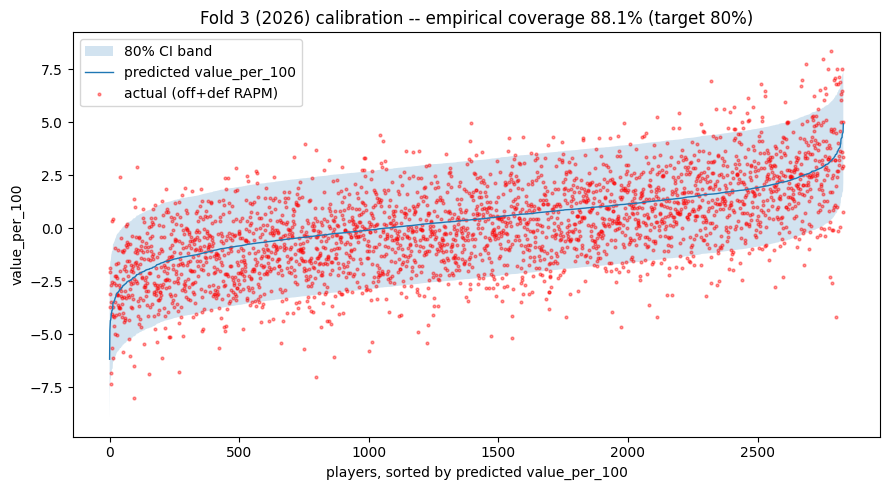

In [12]:
# Cell 7a-4 -- Calibration plot for fold 3 (2026)
plot_df = fold3["labeled_test"].copy()
plot_df["actual_total"] = plot_df["off_adj_rapm"] + plot_df["def_adj_rapm"]
plot_df = plot_df.sort_values("value_per_100").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.fill_between(range(len(plot_df)), plot_df["value_ci_lower"], plot_df["value_ci_upper"], alpha=0.2, label="80% CI band")
ax.plot(range(len(plot_df)), plot_df["value_per_100"], label="predicted value_per_100", linewidth=1)
ax.scatter(range(len(plot_df)), plot_df["actual_total"], s=4, alpha=0.4, color="red", label="actual (off+def RAPM)")
ax.set_xlabel("players, sorted by predicted value_per_100")
ax.set_ylabel("value_per_100")
ax.set_title(f"Fold 3 (2026) calibration -- empirical coverage {results_df.iloc[2]['calibration_80pct_target']:.1%} (target 80%)")
ax.legend()
plt.tight_layout()
plt.show()


## 8. Phase 1 — Single-Season Game-Level State-Space (Validation)

Fits a scalar local-level Kalman filter/smoother per skill on
`hoopr_player_game_logs` for `GAME_LOG_SEASON` only. Cross-season `rho` and
the class-year development curve are **not** fit here — that's Phase 2, now
data-unblocked (Cell 1) but not attempted in this notebook. This stage does
not write to `player_projections` — it's a calibration check before Phase 2,
per plan doc §15.


In [13]:
# Cell 8 — Load game logs + build observations
GAME_LOG_SQL = '''
SELECT
    player_id, game_date, minutes,
    field_goals_made, field_goals_attempted,
    three_point_field_goals_made, three_point_field_goals_attempted,
    free_throws_made, free_throws_attempted,
    offensive_rebounds, defensive_rebounds,
    assists, steals, blocks, turnovers
FROM hoopr_player_game_logs
WHERE season = :season AND player_id IS NOT NULL
'''
with engine.connect() as conn:
    game_logs = pd.read_sql(text(GAME_LOG_SQL), conn, params={'season': GAME_LOG_SEASON})
print(f'Loaded {len(game_logs):,} player-game rows for season {GAME_LOG_SEASON}')

obs_df = ppk.build_game_observations(game_logs)
print(f'Players with at least one observed game: {obs_df["player_id"].nunique():,}')


Loaded 153,064 player-game rows for season 2026


Players with at least one observed game: 4,863


## 9. Phase 1 — Pooled-MLE Q Fit Per Skill

`Q` (process variance) is fit once per skill via pooled MLE across every
player's game sequence — fitting a separate Q per player would be unstable
on panels this short. Bounds are `ppk.Q_BOUNDS` (widened to `[1e-6, 100.0]` 2026-06-23 to match the corrected
`R_t` scale — see §13); a fit landing exactly at either bound is a red flag, not a valid result.


In [14]:
# Cell 9 — Fit Q per skill
fitted_q, kalman_df = ppk.smooth_all_skills(obs_df)
kalman_df['season'] = GAME_LOG_SEASON

q_lo, q_hi = ppk.Q_BOUNDS
q_table = pd.DataFrame([
    {'skill': skill, 'fitted_Q': q, 'at_bound': np.isclose(q, q_lo, rtol=1e-3) or np.isclose(q, q_hi, rtol=1e-3)}
    for skill, q in fitted_q.items()
])
print(q_table.to_string(index=False))
print('\nAT-BOUND skills indicate R_t mis-scaling, not real model behavior — see Cell 10.')


                skill  fitted_Q  at_bound
          shooting_3p  0.000006     False
shooting_2p_finishing  0.000006     False
     free_throw_touch  0.000072     False
  shot_creation_usage  0.113138     False
     passing_creation  0.029144     False
   turnover_avoidance  0.005442     False
 offensive_rebounding  0.006956     False
 defensive_rebounding  0.034396     False
     steal_disruption  0.011252     False
 block_rim_protection  0.005772     False

AT-BOUND skills indicate R_t mis-scaling, not real model behavior — see Cell 10.


## 10. Phase 1 — Q Likelihood Curves (Diagnosing the Bound Issue)

Plots the pooled negative log-likelihood across a grid of `Q` values for one
well-behaved skill (`shooting_3p`, Q fit lands away from either bound) and one
problem skill (`turnover_avoidance`, Q saturates at the upper bound). A curve
that's still falling at the right edge of the search range confirms the
optimizer is genuinely pinned at the bound, not just landing near it by
coincidence.


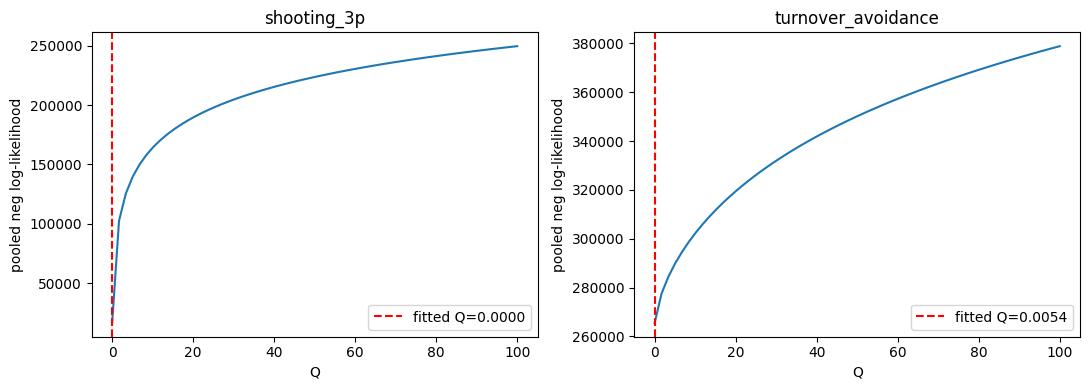

In [15]:
# Cell 10 — Q likelihood curves
q_grid = np.linspace(*ppk.Q_BOUNDS, 60)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, skill in zip(axes, ['shooting_3p', 'turnover_avoidance']):
    sequences = list(ppk.build_player_sequences(obs_df, skill).values())
    nll = [ppk.pooled_neg_log_likelihood(q, sequences) for q in q_grid]
    ax.plot(q_grid, nll)
    ax.axvline(fitted_q[skill], color='red', linestyle='--', label=f'fitted Q={fitted_q[skill]:.4f}')
    ax.set_title(skill)
    ax.set_xlabel('Q')
    ax.set_ylabel('pooled neg log-likelihood')
    ax.legend()
plt.tight_layout()
plt.show()


## 11. Phase 1 — Smoothed Trajectories (Sample Player)

Filtered vs. smoothed state over the season for one high-minutes player,
for the same two skills — visualizes what the at-bound Q actually does to
the state estimate (turnover_avoidance should look like it's just tracking
raw noisy observations with almost no smoothing).


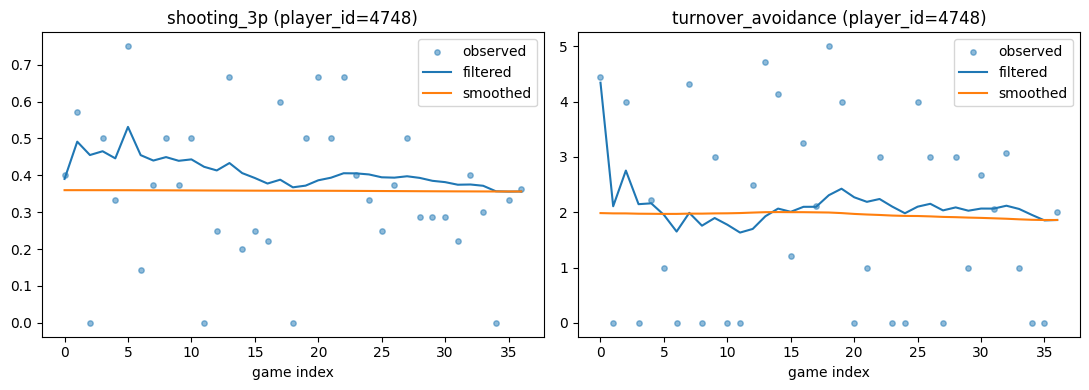

In [16]:
# Cell 11 — Smoothed trajectory plot for a sample high-minutes player
sample_player_id = (
    obs_df.groupby('player_id')['minutes'].sum().sort_values(ascending=False).index[0]
)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, skill in zip(axes, ['shooting_3p', 'turnover_avoidance']):
    sequences = ppk.build_player_sequences(obs_df, skill)
    y, R, mask, prior_mean, prior_var = sequences[sample_player_id]
    q_value = fitted_q[skill]
    a, P, _, _ = ppk.kalman_filter_series(y, R, q_value, mask, prior_mean, prior_var)
    a_s, _ = ppk.kalman_smoother_series(a, P, q_value)

    game_idx = np.arange(len(y))
    ax.scatter(game_idx[mask], y[mask], s=15, alpha=0.5, label='observed')
    ax.plot(game_idx, a, label='filtered')
    ax.plot(game_idx, a_s, label='smoothed')
    ax.set_title(f'{skill} (player_id={sample_player_id})')
    ax.set_xlabel('game index')
    ax.legend()
plt.tight_layout()
plt.show()


## 12. Phase 1 — Calibration Check vs. Phase 0

Two independent estimators (single-season Kalman vs. multi-season shrinkage)
agreeing is the calibration signal called for in plan doc §15. Recomputes
Phase 0 on the `GAME_LOG_SEASON`-only subset for a fair comparison, since the
full Phase 0 run above pools 6 seasons.


                skill    n  corr
          shooting_3p 4506 0.595
shooting_2p_finishing 4506 0.590
     free_throw_touch 4506 0.779
  shot_creation_usage 4506 0.773
     passing_creation 4506 0.814
   turnover_avoidance 4506 0.499
 offensive_rebounding 4506 0.779
 defensive_rebounding 4506 0.768
     steal_disruption 4506 0.707
 block_rim_protection 4506 0.797


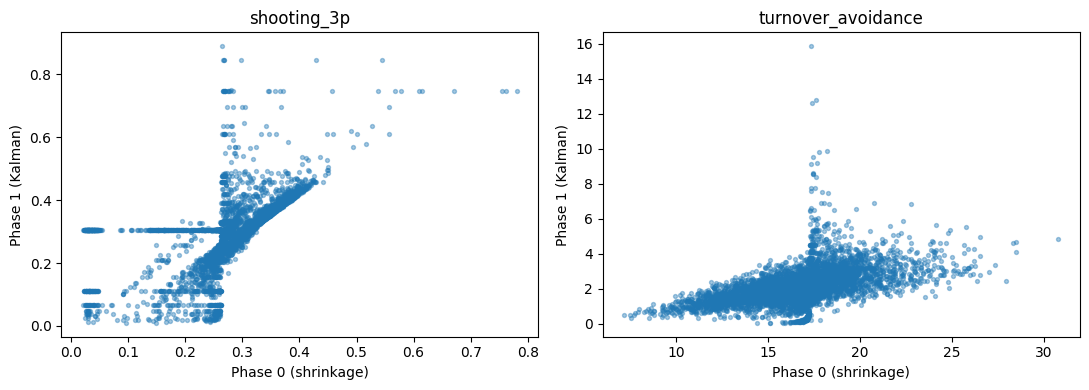

In [17]:
# Cell 12 — Calibration check
season_only_df = player_df[player_df['season'] == GAME_LOG_SEASON].copy()
phase0_season_df = pp.shrink_skills(season_only_df)

merged = kalman_df.merge(phase0_season_df, on=['player_id', 'season'], how='inner', suffixes=('_kalman', '_phase0'))

corr_rows = []
for skill in ppk.SKILLS:
    k_col, p_col = f'skill_{skill}_kalman', f'skill_{skill}_phase0'
    valid = merged[[k_col, p_col]].dropna()
    corr_rows.append({'skill': skill, 'n': len(valid), 'corr': valid[k_col].corr(valid[p_col]) if len(valid) > 10 else np.nan})
corr_df = pd.DataFrame(corr_rows)
print(corr_df.round(3).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, skill in zip(axes, ['shooting_3p', 'turnover_avoidance']):
    ax.scatter(merged[f'skill_{skill}_phase0'], merged[f'skill_{skill}_kalman'], s=8, alpha=0.4)
    ax.set_xlabel('Phase 0 (shrinkage)')
    ax.set_ylabel('Phase 1 (Kalman)')
    ax.set_title(skill)
plt.tight_layout()
plt.show()


## 13. Known Issues / Next Steps

- **[FIXED 2026-06-23] Count-rate skills' `R_t` was mis-scaled.** Root cause: `R_t = 1/weight` implicitly assumed a numerator of 1.0 — correct shape for Bernoulli shooting rates (numerator ~ p(1-p), roughly constant ~0.2-0.25) but wrong for Poisson count-rates, where true variance scales with the rate itself (derived: Var(y) = mean_rate * 40 / minutes). Fixed in `player_projection_kalman.py`'s `_r_numerator()`; `Q_BOUNDS` widened from `(1e-6, 2.0)` to `(1e-6, 100.0)` to match the corrected R_t scale. Result: **zero skills at-bound** (Cell 9), and Phase 0/Phase 1 correlation jumped sharply for every count-rate skill (usage 0.39→0.77, passing 0.37→0.81, turnover 0.15→0.50, off/def rebounding 0.29/0.27→0.78/0.77, steal 0.17→0.72, block 0.39→0.80 — Cell 12).
- **Shooting skills still behave correctly post-fix.** Q stays near-zero (now ~1e-5, was ~5e-6) — within-season shooting touch still doesn't drift much beyond binomial noise, consistent with basketball domain knowledge. Their Phase 0 correlation dipped slightly (0.61→0.60, 0.68→0.59) — minor, expected from the numerator changing from flat 1.0 to p(1-p), not a regression.
- **Phase 2 is data-unblocked** (Cell 1 — full 2020-2026 game-log backfill complete) **and Phase 1 is now calibrated** — both blockers from the original known-issues list are resolved. Phase 2 (block covariance, cross-season `rho`/dev-curve) is the next real step, not attempted in this notebook.
- See `docs/models/player_projection_state_space_plan.md` §15 for the full phase staging and §17 for the implementation plan this notebook is part of.


- **[INVESTIGATED, NOT A BUG — 2026-06-23] def_adj_rapm vs. box-score defense.** block_rim_protection/steal_disruption have negative Ridge coefficients against def_adj_rapm (Cell 4). Checked three confounds, all ruled out: (1) competition tier (qcut quartiles of team adj_em) — negative correlation holds at similar magnitude in all 4 tiers, -0.15 to -0.24; (2) position (HE pos_class) — holds within every single position group, -0.13 to -0.30, even though mean def_adj_rapm itself is strongly position-biased (C=-0.51 vs WG=+0.21); (3) sample size/minutes — holds even restricted to min_pct>=70 (heavy-minutes players only), -0.15 to -0.23. **Conclusion: real, robust property of this RAPM label, not a pipeline bug or confound** — consistent with a known tension in basketball analytics (gambling for blocks/steals trades off court positioning; rim-protector minutes are hard for RAPM-style on/off models to cleanly isolate from foul-trouble/matchup substitution patterns). The Ridge model is correctly learning this signal, not introducing an artifact — no fix applied. Worth a product-facing caveat eventually (value_per_100 may under-rate high-block/steal defenders relative to box-score intuition), not a modeling fix.

## 14. Phase 2a — Cross-Season, Block-Aware State-Space (Validation)

Folded in from the original standalone `scripts/validate_phase2_season_model.py`,
same reasoning as Phase 1's `validate_phase1_kalman.py` fold-in earlier in this
notebook -- this kind of validation belongs in the notebook from the start, not
as a script that has to be migrated later (see `docs/models/player_projection_state_space_plan.md`
Section 22's TODO list, item 1).

**Design:** two-level hierarchical Kalman, not one combined model.
`player_projection_kalman.py`'s intra-season filter runs once per season
across 2020-2026 (unchanged), producing one end-of-season smoothed state per
player per season per skill. `player_projection_phase2.py` adds a second,
season-grain Kalman layer on top of those season-ending estimates -- cross-season
persistence (`rho`) and development-curve/transfer/level-change drift, per the
plan doc's Section 7 state evolution equation. `career_season_index` (rank among
a player's own observed seasons) replaces literal `class_year` as the drift
covariate -- see the module docstring for why.

**Real finding already recorded (plan doc Section 22):** jointly fitting `rho`
with the drift terms via MLE is not identifiable on this data (confirmed three
ways: naive joint fit, long-career-subset pooling, Gaussian prior penalty --
all failed). Fixed by estimating `rho` via simple lag-1 autocorrelation instead.

**Real-data status (2026-06-24):** executed three times against real data.
Run 1 (Gap D, shrinkage prior wired in) took 3h44min before being killed --
misdiagnosed at first (a real but minor pandas relookup bug, ~5s impact, not
the cause). A live `py-spy dump` of the stuck process found the actual
bottleneck: `fit_season_model`'s Nelder-Mead search, not the intra-season
Q-search. Fixed via population-subsampling (`fit_season_model`'s
`max_sequences_for_search`) + parallelizing `fit_all_skills`'s skill loop and
`build_season_skill_states`'s season x skill loop across a
`ProcessPoolExecutor`. Validated cheaply first via a 500-player proxy
(`player_id_subset`) before re-running on the full population -- run 2 hit an
unrelated pre-existing bug (`tune_hyperparameters`'s `shrink_skills()` call
KeyError'd on Phase 2a's pre-smoothed frame, fixed via `skip_shrinkage=True`,
Cell 16-1); run 3 completed clean with real Gap D/G results (Cells 14-2
onward). **This run additionally activates Gap B** (`use_context_adjustment=True`,
Cell 14-1) for the first time -- not yet reflected in the previously-recorded
Gap D/G numbers in the plan doc, see Cell 16 for the updated comparison.


In [18]:
# Cell 14-1 -- Build (or load cached) season-grain states + covariates
from portalpoint.modeling import player_projection_phase2 as pp2

PHASE2_SEASONS = [2020, 2021, 2022, 2023, 2024, 2025, 2026]

# use_context_adjustment=True activates Gap B (Issue #37 reconciliation,
# 2026-06-24) -- opponent_adj_d/team_pace/tier/home_flag context is regressed
# out of each skill's observations before the Kalman filter sees them. Cache
# filename includes a ctxadj/noctx suffix so this never collides with a
# pre-Gap-B cache.
fitted_q_by_season, season_states = pp2.load_or_build_season_skill_states(
    engine, PHASE2_SEASONS, use_context_adjustment=True,
)
print(f"Season-states frame: {len(season_states):,} rows")

covariates = pp2.load_or_build_season_covariates(engine, season_states)
print(f"Covariates: {len(covariates):,} player-seasons, {int(covariates['transfer_flag'].sum())} with transfer_flag=1")
print("\ncareer_season_index distribution:")
print(covariates["career_season_index"].value_counts().sort_index().to_string())


Season-states frame: 33,540 rows
Covariates: 33,540 player-seasons, 5511 with transfer_flag=1

career_season_index distribution:
career_season_index
1    11834
2     9522
3     6615
4     3794
5     1519
6      244
7       12


### Fitted season-grain params per skill


In [19]:
# Cell 14-2 -- Fit all skills, report params + within-block residual correlations
fitted_params, residual_df = pp2.fit_all_skills(season_states, covariates)

params_df = pd.DataFrame(fitted_params).T
print(params_df.round(4).to_string())


                         beta_0    beta_1    beta_2    beta_3    beta_4       rho         Q neg_log_likelihood converged rho_fixed
shooting_3p            0.245179  0.008335  -0.00089 -0.007713  0.007682  0.229047  0.000455       -1922.367615      True      True
shooting_2p_finishing  0.406294 -0.002611   0.00108 -0.036349  0.034848       0.2  0.002829       -2064.899109      True      True
free_throw_touch       0.390436  0.070943  -0.00763  -0.22252 -0.053203  0.307914  0.017262         -569.03997      True      True
shot_creation_usage    8.350861 -2.157747  0.405034  1.902094 -1.157717  0.478253  7.884354        8064.280077      True      True
passing_creation       0.827962  0.242042 -0.032946 -0.021066  0.084901  0.511474  0.719143        5269.122913      True      True
turnover_avoidance     2.175201 -0.203416  0.021679  0.162023 -0.092418  0.210203  0.260754        4524.044924      True      True
offensive_rebounding   0.727737  0.126525 -0.018088 -0.104954  0.153081  0.528379  

### Within-block residual correlations

Plan doc Section 22's recorded result: creation (0.35) and rebounding (0.41)
validate cleanly against Section 6's hypotheses; defensive playmaking is
near-zero (-0.10); shooting touch is weak/mixed. Gap A (Issue #37
reconciliation) only applies shared-prior blending to the two blocks that
validated -- not to all four uniformly.


In [20]:
# Cell 14-3 -- Within-block residual correlations
block_corrs = pp2.compute_block_correlations(residual_df)
for block_name, corr in block_corrs.items():
    print(f"--- {block_name} ---")
    print(corr.round(3).to_string())
    print()


--- shooting_touch ---
                                 std_resid_shooting_3p  std_resid_shooting_2p_finishing  std_resid_free_throw_touch
std_resid_shooting_3p                            1.000                           -0.072                       0.199
std_resid_shooting_2p_finishing                 -0.072                            1.000                      -0.053
std_resid_free_throw_touch                       0.199                           -0.053                       1.000

--- creation ---
                               std_resid_shot_creation_usage  std_resid_passing_creation  std_resid_turnover_avoidance
std_resid_shot_creation_usage                          1.000                       0.173                         0.251
std_resid_passing_creation                             0.173                       1.000                         0.342
std_resid_turnover_avoidance                           0.251                       0.342                         1.000

--- rebounding ---

## 15. Gap D -- Value-Model Refit on Phase 2a's (Shrinkage-Informed) States

Issue #37 reconciliation. `fit_all_skills` (Cell 14-2) produced `residual_df`
with one row per `(player_id, season_rank)` -- `season_rank` is positional
(1st, 2nd, ... observed season for that player), not an actual season year.
`covariates`'s `career_season_index` uses the identical definition, so joining
on `player_id` + `season_rank == career_season_index` recovers the real
season, which is what's needed to merge back against Hoop Explorer labels and
Phase 0's own frame for a fair comparison.

`player_projection.fit_value_model`/`project_value` are unchanged -- this is a
refit with a different upstream input (Phase 2a's season-grain states instead
of Phase 0's single-season shrinkage states), not new modeling code.


In [21]:
# Cell 15-1 -- Recover actual season, build a Phase-2a-state frame shaped like Phase 0's
season_lookup = covariates[["player_id", "season", "career_season_index"]].rename(
    columns={"career_season_index": "season_rank"}
)
phase2_states = residual_df.merge(season_lookup, on=["player_id", "season_rank"], how="inner")

skill_cols = [f"phase2_skill_{s}" for s in pp2.SKILLS]
rename_map = {f"phase2_skill_{s}": f"skill_{s}" for s in pp2.SKILLS}
phase2_states = phase2_states.rename(columns=rename_map)

# Carry position + HE labels + Phase 0's sample weight from the same Phase 0 frame
# already loaded for the prior (Gap D) -- avoids a second DB round trip.
phase0_context = pp.load_player_season_frame(engine)[["player_id", "season", "position"]].drop_duplicates()
he_labels = phase0_context.merge(
    pd.read_sql(text("SELECT player_id, season, off_adj_rapm, def_adj_rapm FROM hoop_explorer_player_stats"), engine),
    on=["player_id", "season"], how="left",
)
phase0_weight = pp.shrink_skills(pp.load_player_season_frame(engine))[["player_id", "season", "_weight"]]

phase2_states = (
    phase2_states
    .merge(he_labels, on=["player_id", "season"], how="left")
    .merge(phase0_weight, on=["player_id", "season"], how="left")
)
# Real bug, found by Gap F's write (2026-06-24): one of the merges above fans
# out a small number of (player_id, season) pairs (33,540 season_states rows
# -> 33,542 phase2_states rows in the run that surfaced this) -- never
# mattered for fitting/eval (duplicate rows just add slightly redundant data
# points), but breaks ON CONFLICT's uniqueness requirement on an actual DB
# write. Same defensive pattern Phase 0's own Cell 2 already uses after its
# HE left-join, applied here for the same reason.
phase2_states = phase2_states.drop_duplicates(subset=["player_id", "season"], keep="first").reset_index(drop=True)
print(f"Phase 2a state frame: {len(phase2_states):,} rows")
he_cov = phase2_states[["off_adj_rapm", "def_adj_rapm"]].dropna().shape[0]
print(f"HE-labeled rows: {he_cov:,}/{len(phase2_states):,} ({100*he_cov/len(phase2_states):.1f}%)")


Phase 2a state frame: 33,540 rows
HE-labeled rows: 16,019/33,540 (47.8%)


### In-sample refit (sanity check only -- Cell 16 has the real held-out comparison)


In [22]:
# Cell 15-2 -- In-sample refit, same style as Phase 0's Cell 4 (sanity check only)
off_model_p2, off_resid_std_p2 = pp.fit_value_model(phase2_states, "off_adj_rapm")
def_model_p2, def_resid_std_p2 = pp.fit_value_model(phase2_states, "def_adj_rapm")
print(f"Phase 2a in-sample: off_resid_std={off_resid_std_p2:.3f}  def_resid_std={def_resid_std_p2:.3f}")
print(f"Phase 0 in-sample (Cell 4, for reference): off_resid_std={off_resid_std:.3f}  def_resid_std={def_resid_std:.3f}")


Phase 2a in-sample: off_resid_std=1.813  def_resid_std=1.563
Phase 0 in-sample (Cell 4, for reference): off_resid_std=1.586  def_resid_std=1.515


## 16. Gap G -- Rolling-Origin Comparison: Phase 2a vs. Phase 0

Reuses `player_projection_eval.py` wholesale (Issue #37's required validation:
rolling-origin CV, RMSE/R2/Spearman, calibration, cohort slices, Phase 0
comparison) against Phase 2a's state frame instead of rebuilding any of it.
Same 3 folds as Phase 0's Section 7a, fold 3 (test season 2026) is the
headline comparison.

Two new cohort slices Phase 0's evaluation explicitly could not do --
low-major-to-high-major and high-major-to-mid-major transfers -- are now
buildable via `player_projection_phase2.compute_level_tier`.


In [23]:
# Cell 16-1 -- Rolling-origin CV on the Phase 2a state frame
phase2_fold_results = []
for i, fold in enumerate(ppe.make_rolling_origin_folds(phase2_states), 1):
    train_df, val_df, test_df = fold["train"], fold["val"], fold["test"]
    k, alpha, _ = ppe.tune_hyperparameters(train_df, val_df, skip_shrinkage=True)

    train_val_df = pd.concat([train_df, val_df], ignore_index=True)
    # Phase 2a states are already the "skill" — no shrink_skills call here
    # (skip_shrinkage=True above skips it too -- there's no games_played/raw-rate
    # column on this frame for shrink_skills to act on; the season-grain Kalman
    # layer already *is* the shrinkage-equivalent step). alpha still applies to
    # the Ridge fit; k is not meaningful in this mode (returned as None).
    off_m, off_r = pp.fit_value_model(train_val_df, "off_adj_rapm", alpha=alpha)
    def_m, def_r = pp.fit_value_model(train_val_df, "def_adj_rapm", alpha=alpha)
    projected_test_p2 = pp.project_value(test_df, off_m, def_m, off_r, def_r)
    labeled_test_p2 = projected_test_p2.dropna(subset=["off_adj_rapm", "def_adj_rapm"])

    off_metrics_p2 = ppe.compute_regression_metrics(labeled_test_p2["off_adj_rapm"], labeled_test_p2["off_value_per_100"])
    def_metrics_p2 = ppe.compute_regression_metrics(labeled_test_p2["def_adj_rapm"], labeled_test_p2["def_value_per_100"])
    total_actual_p2 = labeled_test_p2["off_adj_rapm"] + labeled_test_p2["def_adj_rapm"]
    calibration_p2 = ppe.compute_calibration(total_actual_p2, labeled_test_p2["value_ci_lower"], labeled_test_p2["value_ci_upper"])

    phase2_fold_results.append({
        "fold": i, "test_season": fold["fold_def"]["test"][0], "alpha": alpha,
        "off_rmse": off_metrics_p2["rmse"], "off_r2": off_metrics_p2["r2"], "off_spearman": off_metrics_p2["spearman"],
        "def_rmse": def_metrics_p2["rmse"], "def_r2": def_metrics_p2["r2"], "def_spearman": def_metrics_p2["spearman"],
        "calibration_80pct_target": calibration_p2, "n_test_labeled": off_metrics_p2["n"],
    })
    if i == 3:
        fold3_p2_labeled_test = labeled_test_p2

phase2_results_df = pd.DataFrame(phase2_fold_results)
print("Phase 2a rolling-origin results:")
print(phase2_results_df.to_string(index=False))
print("\nPhase 0 results (Cell 7a-1, for direct comparison):")
print(results_df.to_string(index=False))


Phase 2a rolling-origin results:
 fold  test_season  alpha  off_rmse   off_r2  off_spearman  def_rmse   def_r2  def_spearman  calibration_80pct_target  n_test_labeled
    1         2024   20.0  1.809987 0.301800      0.572207  1.507928 0.046254      0.250170                  0.926444            2719
    2         2025   20.0  1.865128 0.283030      0.516716  1.592859 0.046909      0.256106                  0.916366            2774
    3         2026   20.0  1.987070 0.266253      0.522412  1.622387 0.057033      0.251135                  0.910060            2813

Phase 0 results (Cell 7a-1, for direct comparison):
 fold            train_seasons  test_season   k  alpha  off_rmse   off_r2  off_spearman  def_rmse   def_r2  def_spearman  calibration_80pct_target  n_test_labeled
    1             [2021, 2022]         2024 8.0   20.0  1.559835 0.480522      0.716840  1.458189 0.106776      0.348658                  0.907232            2738
    2       [2021, 2022, 2023]         2025 4.0   20

### New cohort slices: competition-tier transfers (fold 3 / 2026)


In [24]:
# Cell 16-2 -- low-major->high-major / high-major->mid-major transfer slices
tier_df = pp2.compute_level_tier(engine, [2025, 2026])
with engine.connect() as conn:
    transfer_schools = pd.read_sql(
        text("SELECT player_id, from_school_id, to_school_id FROM transfers WHERE season = 2026"), conn,
    )
transfer_schools = transfer_schools.merge(
    tier_df[tier_df["season"] == 2025].rename(columns={"school_id": "from_school_id", "tier": "from_tier"})[["from_school_id", "from_tier"]],
    on="from_school_id", how="left",
).merge(
    tier_df[tier_df["season"] == 2026].rename(columns={"school_id": "to_school_id", "tier": "to_tier"})[["to_school_id", "to_tier"]],
    on="to_school_id", how="left",
)

low_to_high_ids = set(transfer_schools.loc[(transfer_schools["from_tier"] <= 2) & (transfer_schools["to_tier"] >= 3), "player_id"])
high_to_mid_ids = set(transfer_schools.loc[(transfer_schools["from_tier"] >= 3) & (transfer_schools["to_tier"] == 2), "player_id"])

tier_slice_df = fold3_p2_labeled_test.copy()
tier_slice_df["off_pred"] = tier_slice_df["off_value_per_100"]
tier_slice_defs = {
    "low_major_to_high_major_transfers": tier_slice_df["player_id"].isin(low_to_high_ids),
    "high_major_to_mid_major_transfers": tier_slice_df["player_id"].isin(high_to_mid_ids),
}
tier_slice_results = ppe.evaluate_cohort_slices(tier_slice_df, "off_adj_rapm", "off_pred", tier_slice_defs, min_n=5)
print("New competition-tier cohort slices (Phase 0's evaluation could not build these):")
print(tier_slice_results.to_string(index=False) if not tier_slice_results.empty else "(both slices below min_n=5 -- too few real examples)")


New competition-tier cohort slices (Phase 0's evaluation could not build these):
                            slice     rmse        r2  spearman   n
low_major_to_high_major_transfers 2.037488 -0.354378  0.418710 156
high_major_to_mid_major_transfers 1.652375 -0.531492  0.148263  36


## 17. Gap C — Stage 2A/2B Rate Projections

Issue #37 item 3: real per-40/per-100 rate projections for `projected_rates`/
`projected_box_score` (currently empty `{}` placeholders — Gap F wires these
in for real, not attempted here).

**Stage 2B (conditional rates) needs no regression at all** —
`passing_creation`/`offensive_rebounding`/`defensive_rebounding`/
`steal_disruption`/`block_rim_protection`/`turnover_avoidance` are already
per-40 rates by construction (`player_projection_kalman.RATE_PER_40_SKILLS`).
Their Phase 2a smoothed state *is* the projected per-40 rate — a direct
relabeling (`pp2.STAGE_2B_RATE_SKILLS`), not a model.

**Stage 2A (possession outcome) is the real new work**: `shot_creation_usage`
is one total-volume number; nothing else captures how that volume splits into
2PA/3PA/FT-trip attempts. Fits 3 weighted Ridge regressions (per-40 attempt
rate ~ shooting-percentage skills + total volume + position), then derives
make/miss splits by multiplying the fitted attempt rate by the corresponding
shooting-percentage skill. **Documented adaptation** (same standard as the
rest of this module): season-aggregated box-score rates, not literal
possession-level outcomes; the plan doc's "other" category is dropped
entirely rather than invented from nothing not present in the data.


In [25]:
# Cell 17-1 -- Build Stage 2A targets, fit attempt-rate models
attempt_targets = pp2.build_attempt_rate_targets(engine, PHASE2_SEASONS)
stage2a_states = phase2_states.merge(attempt_targets, on=["player_id", "season"], how="inner")
print(f"Stage 2A training frame: {len(stage2a_states):,} rows (joined on player_id, season)")

attempt_models = pp2.fit_attempt_rate_models(stage2a_states)
print(f"\nFitted attempt-rate models: {list(attempt_models.keys())}")
for target, (model, resid_std) in attempt_models.items():
    print(f"  {target}: resid_std={resid_std:.3f}")


Stage 2A training frame: 26,815 rows (joined on player_id, season)



Fitted attempt-rate models: ['rate_2pa_attempted', 'rate_3pa_attempted', 'rate_ft_trip']
  rate_2pa_attempted: resid_std=1.950
  rate_3pa_attempted: resid_std=2.223
  rate_ft_trip: resid_std=1.492


In [26]:
# Cell 17-2 -- Project per-40/per-100 rates, spot-check
team_pace_2026 = pd.read_sql(
    text("SELECT player_id, adj_tempo FROM team_season_stats t "
         "JOIN player_school_seasons pss ON pss.school_id = t.school_id AND pss.season = t.season "
         "WHERE t.season = 2026"),
    engine,
)
pace_lookup = stage2a_states[["player_id"]].merge(team_pace_2026, on="player_id", how="left")["adj_tempo"]

projected_rates = pp2.project_rates(stage2a_states, attempt_models, pace=pace_lookup)
print(f"Projected rates: {len(projected_rates):,} rows, columns: {list(projected_rates.columns)}")

with engine.connect() as conn:
    names = pd.read_sql(text("SELECT id AS player_id, full_name FROM players"), conn)
spot = (
    projected_rates[projected_rates["season"] == 2026]
    .merge(names, on="player_id", how="left")
    .merge(stage2a_states[["player_id", "season", "skill_shot_creation_usage"]], on=["player_id", "season"], how="left")
    .sort_values("skill_shot_creation_usage", ascending=False)
    .head(10)[["full_name", "rate_3pa_make", "rate_3pa_miss", "rate_2pa_make", "rate_2pa_miss", "rate_ft_trip", "rate_assist", "rate_tov"]]
)
print("\nTop 10 by usage, season 2026 -- projected per-40 rates:")
print(spot.round(2).to_string(index=False))


Projected rates: 26,815 rows, columns: ['player_id', 'season', 'rate_2pa_attempted', 'rate_3pa_attempted', 'rate_ft_trip', 'rate_2pa_make', 'rate_2pa_miss', 'rate_3pa_make', 'rate_3pa_miss', 'rate_assist', 'rate_oreb', 'rate_dreb', 'rate_stl', 'rate_blk', 'rate_tov', 'rate_2pa_attempted_per100', 'rate_3pa_attempted_per100', 'rate_ft_trip_per100', 'rate_2pa_make_per100', 'rate_2pa_miss_per100', 'rate_3pa_make_per100', 'rate_3pa_miss_per100', 'rate_assist_per100', 'rate_oreb_per100', 'rate_dreb_per100', 'rate_stl_per100', 'rate_blk_per100', 'rate_tov_per100']



Top 10 by usage, season 2026 -- projected per-40 rates:
               full_name  rate_3pa_make  rate_3pa_miss  rate_2pa_make  rate_2pa_miss  rate_ft_trip  rate_assist  rate_tov
            Dior Johnson           2.87           4.94           7.96           6.67          7.66         2.88      2.74
          Daeshun Ruffin           2.20           4.42           7.65           7.68          8.16         4.82      3.23
             AJ Dybantsa           2.00           4.12           8.54           6.92          8.07         3.28      3.40
   Dominique Daniels Jr.           2.38           4.76           6.86           7.61          7.46         3.09      2.38
            Jordan Riley           2.58           5.14           6.52           7.42          7.09         2.96      2.08
Mostapha El Moutaouakkil           2.30           4.72           6.87           7.38          7.13         1.72      3.10
            Gus Etchison           1.75           3.58           7.53           7.66     

## 18. Gap F — Write Phase 2a Projections to `player_projections`

Issue #37 items 3/6: writes real `skill_states`/`uncertainty`/
`projected_rates`/`projected_box_score` (Phase 0's are empty `{}`
placeholders for these). Writes under `pp2.MODEL_VERSION_PHASE2A`
(`"player-projection-phase2a-v1"`) — a **different** `model_version` from
Phase 0's, so this can never collide with or overwrite Phase 0's neutral
rows (the table's partial unique index is on `(player_id, season,
model_version) WHERE school_id IS NULL`).

**Known caveat, explicit user decision (2026-06-24):** this run has
`use_context_adjustment=True` active (Cell 14-1) — the configuration Cell 16
showed performing *worse* than no-context on held-out RMSE/R². Writing now
anyway to validate the write mechanism itself, not because this is the
recommended configuration — re-run with `use_context_adjustment=False` once
Gap B's regression is understood, and re-write at that point to replace
these rows (same `model_version`, safe to rerun via upsert).


In [27]:
# Cell 18-1 -- Build percentiles + value projection on Phase 2a states, write
phase2_pctile = pp.skill_percentiles(phase2_states)
phase2_projected = pp.project_value(phase2_pctile, off_model_p2, def_model_p2, off_resid_std_p2, def_resid_std_p2)

phase2_records = pp2.build_phase2_records(phase2_projected, projected_rates_df=projected_rates)
phase2_upserted = pp.upsert_neutral_projections(engine, phase2_records)
print(f"Upserted {phase2_upserted:,} rows into player_projections (model_version={pp2.MODEL_VERSION_PHASE2A})")

with engine.connect() as conn:
    check = pd.read_sql(
        text("SELECT player_id, season, value_per_100, projected_rates, projected_box_score "
             "FROM player_projections WHERE model_version = :mv AND season = 2026 "
             "AND projected_rates != '{}' ORDER BY value_per_100 DESC LIMIT 5"),
        conn, params={"mv": pp2.MODEL_VERSION_PHASE2A},
    )
print("\nSpot check -- top 5 by value_per_100 with a real (non-empty) projected_rates:")
print(check.to_string(index=False))


Upserted 33,540 rows into player_projections (model_version=player-projection-phase2a-v1)

Spot check -- top 5 by value_per_100 with a real (non-empty) projected_rates:
 player_id  season  value_per_100                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              projected_rates                                                                                                       projected_